# Ti-6Al-4V SLM Vickers Hardness 회귀 — 4가지 시나리오

**Goal:** 공정변수 / 기공률 / OM 이미지(CNN 피처)를 단계적으로 결합하여 비커스 경도 예측 R² 향상.

| 시나리오 | 입력 피처 |
|---|---|
| 1. Baseline | 공정 파라미터 (Layer thickness, Power, Speed, Energy density) |
| 2. + Porosity | 공정 파라미터 + 기공률 |
| 3. + Image | 공정 파라미터 + CNN(ResNet18) 추출 피처 |
| 4. Full | 공정 파라미터 + 기공률 + CNN 피처 |

**Models:** SVR(RBF), GPR(RBF+White), Averaging Ensemble  
**Scaling:** Min-Max only (표준화 금지)  
**Evaluation:** LOOCV R², 5-Fold CV R² (mean ± std)

## 0. 환경 설정 및 라이브러리

In [33]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torchvision import models, transforms

warnings.filterwarnings('ignore')
np.random.seed(42); torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch:', torch.__version__, '| device:', DEVICE)

torch: 2.11.0+cpu | device: cpu


## 1. 데이터 로드 (공정변수 + 경도 + 기공률)

병합 CSV는 이전 단계(visualization 노트북)에서 생성된 `results/porosity_hardness_merged.csv`를 사용한다.  
경도 측정값이 있는 샘플만 회귀 대상으로 남긴다.

In [34]:
DATA_CSV = 'results/porosity_hardness_merged.csv'
IMG_DIR  = '이미지_OM_단면'

df_raw = pd.read_csv(DATA_CSV)
df = df_raw.dropna(subset=['hardness']).reset_index(drop=True).copy()

# 기공률 컬럼명 통일 (porosity_ratio → porosity)
df = df.rename(columns={'porosity_ratio': 'porosity'})

PROC_COLS = ['layer_thickness', 'power', 'scan_speed', 'energy_density']
POR_COLS  = ['porosity']
TARGET    = 'hardness'

# 기공률이 NaN인 행은 시나리오 2/4에서 사용 불가 → 평균값으로 보간
df['porosity'] = df['porosity'].fillna(df['porosity'].mean())

print('샘플 수:', len(df))
print('경도 범위:', df[TARGET].min(), '~', df[TARGET].max(), 'HV')
df.head()


샘플 수: 77
경도 범위: 348.625 ~ 403.875 HV


,code,layer_thickness,power,scan_speed,energy_density,hardness,porosity,defect_count,mean_defect_area,max_defect_area,total_defect_area
0,TIT2P1SS1,50.0,80.0,433.0,19.707,366.975,0.046563,53.000000,1799.714612,21339.666667,86400.500000
1,TIT2P2SS1,50.0,160.0,433.0,39.415,378.375,0.020151,57.666667,620.086786,3592.500000,36171.500000
2,TIT2P2SS2,50.0,160.0,866.0,19.707,374.325,0.000340,2.666667,195.083333,392.166667,563.666667
3,TIT2P3SS1,50.0,240.0,433.0,59.122,371.800,0.032707,53.666667,1125.423313,5477.833333,59643.166667
4,TIT2P3SS2,50.0,240.0,866.0,29.561,375.775,0.000014,0.333333,10.000000,10.000000,10.000000


## 2. 모델/평가 유틸리티

- `make_models()`: SVR(RBF) + GPR(C·RBF + WhiteKernel) 동일 설정 재현
- `evaluate(X, y)`: Min-Max → LOOCV R² + 5-Fold(mean/std) 일괄 산출
- `Ensemble`: SVR 예측과 GPR 예측의 단순 평균(Averaging)

In [35]:
def make_models():
    """SVR(RBF) + GPR(isotropic RBF + White) 동일 하이퍼파라미터로 매번 새로 생성."""
    svr = SVR(kernel='rbf', C=10.0, gamma='scale', epsilon=0.1)
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))              + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    gpr = GaussianProcessRegressor(
        kernel=kernel, normalize_y=True, alpha=1e-6,
        n_restarts_optimizer=5, random_state=42,
    )
    return svr, gpr


def fit_predict(model_name, X_tr, y_tr, X_te):
    """단일 분할에 대해 SVR / GPR / Ensemble 예측을 반환."""
    svr, gpr = make_models()
    if model_name == 'SVR':
        return svr.fit(X_tr, y_tr).predict(X_te)
    if model_name == 'GPR':
        return gpr.fit(X_tr, y_tr).predict(X_te)
    # Ensemble: 두 모델 예측의 평균
    p_svr = svr.fit(X_tr, y_tr).predict(X_te)
    p_gpr = gpr.fit(X_tr, y_tr).predict(X_te)
    return 0.5 * (p_svr + p_gpr)


def evaluate(X, y, scenario_name, k=5, verbose=True):
    """Min-Max 스케일 후 LOOCV / K-Fold 결과를 dict 로 반환."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    Xs = MinMaxScaler().fit_transform(X)

    out = {}
    # ---- LOOCV ----
    loo = LeaveOneOut()
    for name in ['SVR', 'GPR', 'Ensemble']:
        preds = np.zeros_like(y)
        for tr, te in loo.split(Xs):
            preds[te] = fit_predict(name, Xs[tr], y[tr], Xs[te])
        out[(name, 'LOOCV_R2')] = r2_score(y, preds)

    # ---- K-Fold ----
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    for name in ['SVR', 'GPR', 'Ensemble']:
        fold_r2 = []
        for tr, te in kf.split(Xs):
            pred = fit_predict(name, Xs[tr], y[tr], Xs[te])
            fold_r2.append(r2_score(y[te], pred))
        out[(name, f'KFold{k}_mean')] = float(np.mean(fold_r2))
        out[(name, f'KFold{k}_std')]  = float(np.std(fold_r2))

    if verbose:
        print(f'[{scenario_name}]  features = {X.shape[1]}, n = {X.shape[0]}')
        for m in ['SVR', 'GPR', 'Ensemble']:
            print(f'  {m:<9} | LOOCV R² = {out[(m,"LOOCV_R2")]:+.4f} | '
                  f'5-Fold R² = {out[(m,"KFold5_mean")]:+.4f} ± {out[(m,"KFold5_std")]:.4f}')
    return out


## 3. 시나리오 1 — Baseline (공정 파라미터만)

In [36]:
y = df[TARGET].values

X_s1 = df[PROC_COLS].values
res_s1 = evaluate(X_s1, y, 'Scenario 1: Process only')

[Scenario 1: Process only]  features = 4, n = 77
  SVR       | LOOCV R² = +0.2895 | 5-Fold R² = +0.2678 ± 0.1225
  GPR       | LOOCV R² = -0.1155 | 5-Fold R² = -0.0865 ± 0.1442
  Ensemble  | LOOCV R² = +0.1510 | 5-Fold R² = +0.1607 ± 0.0702


## 4. 시나리오 2 — 공정 파라미터 + 기공률

In [37]:
X_s2 = df[PROC_COLS + POR_COLS].values
res_s2 = evaluate(X_s2, y, 'Scenario 2: Process + Porosity')

[Scenario 2: Process + Porosity]  features = 5, n = 77
  SVR       | LOOCV R² = +0.2033 | 5-Fold R² = +0.1960 ± 0.1383
  GPR       | LOOCV R² = -0.0070 | 5-Fold R² = -0.1039 ± 0.1066
  Ensemble  | LOOCV R² = +0.1497 | 5-Fold R² = +0.1058 ± 0.1085


## 5. CNN 피처 추출 (시나리오 3, 4 공용 준비 단계)

### 5-1. CNN 피처 추출기 정의
사전 학습된 ResNet18에서 마지막 FC 직전(Avgpool 출력, 512-D)을 추출한다.  
ImageNet 가중치를 동결해 사용하며, OM 이미지를 224×224로 리사이즈/정규화한 뒤 backbone에 통과시킨다.

In [38]:
class CNNFeatureExtractor(nn.Module):
    """OM 단면 이미지를 받아 Flatten 벡터(512-D)를 반환하는 ResNet18 backbone."""
    def __init__(self, backbone='resnet18'):
        super().__init__()
        if backbone == 'resnet18':
            net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            self.feature_dim = net.fc.in_features  # 512
            net.fc = nn.Identity()
        elif backbone == 'vgg16':
            net = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
            net.classifier = nn.Sequential(*list(net.classifier.children())[:-1])
            self.feature_dim = 4096
        else:
            raise ValueError(backbone)
        self.backbone = net
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.backbone(x)


# ImageNet 통계 정규화 (사전 학습 모델 호환)
IMNET_MEAN = [0.485, 0.456, 0.406]
IMNET_STD  = [0.229, 0.224, 0.225]

# 평가용: 결정적 변환
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])

# 증강용: Rotation + RandomCrop + Flip
aug_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])

### 5-2. 코드별 OM 이미지 → CNN 피처 평균

한 코드(예: `TIT2P3SS4`)당 보통 3장의 단면 이미지가 있다.  
각 이미지를 결정적 1회 + 증강 `n_aug`회 추출 후 모든 벡터를 평균하여 코드 단위 피처를 만든다.  
이미지가 없는 코드는 전체 평균 벡터로 대체한다.

In [39]:
def load_code_images(code, img_dir=IMG_DIR):
    """코드 prefix 로 해당 폴더의 모든 jpg 를 PIL.Image(RGB) 리스트로 로드.

    Windows + 한글(non-ASCII) 경로에서는 cv2.imread 가 silently None 을 반환하므로
    PIL.Image.open 을 사용한다. (cv2 가 꼭 필요하면 np.fromfile + cv2.imdecode 패턴 사용)
    """
    paths = sorted(glob.glob(os.path.join(img_dir, f'{code}_*.jpg')))
    pil_images = []
    for p in paths:
        try:
            pil_images.append(Image.open(p).convert('RGB'))
        except Exception as e:
            print(f'[warn] {p} 로드 실패: {e}')
    return pil_images


@torch.no_grad()
def extract_features_for_codes(codes, model, n_aug=4, batch_size=32, device=DEVICE):
    model.eval().to(device)
    feats = {}
    for code in codes:
        pil_imgs = load_code_images(code)
        if not pil_imgs:
            feats[code] = None
            continue
        tensors = []
        for img in pil_imgs:
            tensors.append(eval_tf(img))
            for _ in range(n_aug):
                tensors.append(aug_tf(img))
        # 배치 단위 forward
        all_vecs = []
        for i in range(0, len(tensors), batch_size):
            batch = torch.stack(tensors[i:i+batch_size]).to(device)
            all_vecs.append(model(batch).cpu().numpy())
        feats[code] = np.concatenate(all_vecs, axis=0).mean(axis=0)

    # 누락 코드 → 전체 평균으로 보간
    valid = [v for v in feats.values() if v is not None]
    if not valid:
        # 디버그 정보 출력 후 에러
        sample_code = codes[0]
        sample_paths = sorted(glob.glob(os.path.join(IMG_DIR, f'{sample_code}_*.jpg')))
        raise RuntimeError(
            f'이미지가 하나도 매칭되지 않았습니다. '
            f'IMG_DIR={IMG_DIR!r}, cwd={os.getcwd()!r}, '
            f"sample code={sample_code!r}, glob 결과={sample_paths[:3]}"
        )
    mean_vec = np.mean(valid, axis=0)
    n_missing = sum(v is None for v in feats.values())
    for k, v in feats.items():
        if v is None:
            feats[k] = mean_vec
    print(f'CNN 피처 추출 완료 — 코드 {len(codes)}개 (누락 보간 {n_missing}개), dim = {len(mean_vec)}')
    return feats


cnn = CNNFeatureExtractor('resnet18')
feat_dict = extract_features_for_codes(df['code'].tolist(), cnn, n_aug=4, device=DEVICE)
X_img = np.array([feat_dict[c] for c in df['code'].tolist()])
print('이미지 피처 행렬:', X_img.shape)


CNN 피처 추출 완료 — 코드 77개 (누락 보간 0개), dim = 512
이미지 피처 행렬: (77, 512)


### 5-3. PCA 차원 축소

샘플 77개 vs 피처 512차원 — 차원 저주 회피 위해 PCA로 10차원으로 압축한다.  
(시나리오 3·4에서 동일하게 사용.)

In [40]:
N_PCA = 10
pca = PCA(n_components=min(N_PCA, X_img.shape[0] - 1, X_img.shape[1]), random_state=42)
X_img_pca = pca.fit_transform(X_img)
print(f'PCA: {X_img.shape[1]}D → {X_img_pca.shape[1]}D, 누적 설명 분산 = {pca.explained_variance_ratio_.sum():.3f}')

PCA: 512D → 10D, 누적 설명 분산 = 0.937


## 6. 시나리오 3 — 공정 파라미터 + CNN 피처

In [41]:
X_s3 = np.hstack([df[PROC_COLS].values, X_img_pca])
res_s3 = evaluate(X_s3, y, 'Scenario 3: Process + CNN')

[Scenario 3: Process + CNN]  features = 14, n = 77
  SVR       | LOOCV R² = +0.2136 | 5-Fold R² = +0.1243 ± 0.2633
  GPR       | LOOCV R² = +0.1729 | 5-Fold R² = +0.1605 ± 0.2619
  Ensemble  | LOOCV R² = +0.2172 | 5-Fold R² = +0.1828 ± 0.2564


## 7. 시나리오 4 — Full Integration (공정 + 기공률 + CNN)

In [42]:
X_s4 = np.hstack([df[PROC_COLS + POR_COLS].values, X_img_pca])
res_s4 = evaluate(X_s4, y, 'Scenario 4: Process + Porosity + CNN')

[Scenario 4: Process + Porosity + CNN]  features = 15, n = 77
  SVR       | LOOCV R² = +0.2037 | 5-Fold R² = +0.1037 ± 0.2690
  GPR       | LOOCV R² = +0.1753 | 5-Fold R² = +0.1551 ± 0.2702
  Ensemble  | LOOCV R² = +0.2160 | 5-Fold R² = +0.1705 ± 0.2644


## 8. 결과 통합 — DataFrame 요약

In [43]:
all_results = {
    'S1: Process':            res_s1,
    'S2: + Porosity':         res_s2,
    'S3: + CNN':              res_s3,
    'S4: Process+Por+CNN':    res_s4,
}

rows = []
for scen, d in all_results.items():
    for (model, metric), val in d.items():
        rows.append({'Scenario': scen, 'Model': model, 'Metric': metric, 'Value': val})
long_df = pd.DataFrame(rows)

summary_df = long_df.pivot_table(
    index=['Scenario', 'Model'], columns='Metric', values='Value'
).reindex(columns=['LOOCV_R2', 'KFold5_mean', 'KFold5_std'])
summary_df = summary_df.round(4)
summary_df.to_csv('results/scenario_comparison.csv')
summary_df

Metric                        LOOCV_R2  KFold5_mean  KFold5_std
Scenario            Model                                      
S1: Process         Ensemble    0.1510       0.1607      0.0702
                    GPR        -0.1155      -0.0865      0.1442
                    SVR         0.2895       0.2678      0.1225
S2: + Porosity      Ensemble    0.1497       0.1058      0.1085
                    GPR        -0.0070      -0.1039      0.1066
                    SVR         0.2033       0.1960      0.1383
S3: + CNN           Ensemble    0.2172       0.1828      0.2564
                    GPR         0.1729       0.1605      0.2619
                    SVR         0.2136       0.1243      0.2633
S4: Process+Por+CNN Ensemble    0.2160       0.1705      0.2644
                    GPR         0.1753       0.1551      0.2702
                    SVR         0.2037       0.1037      0.2690

## 9. 시각화 — 시나리오 × 모델 비교

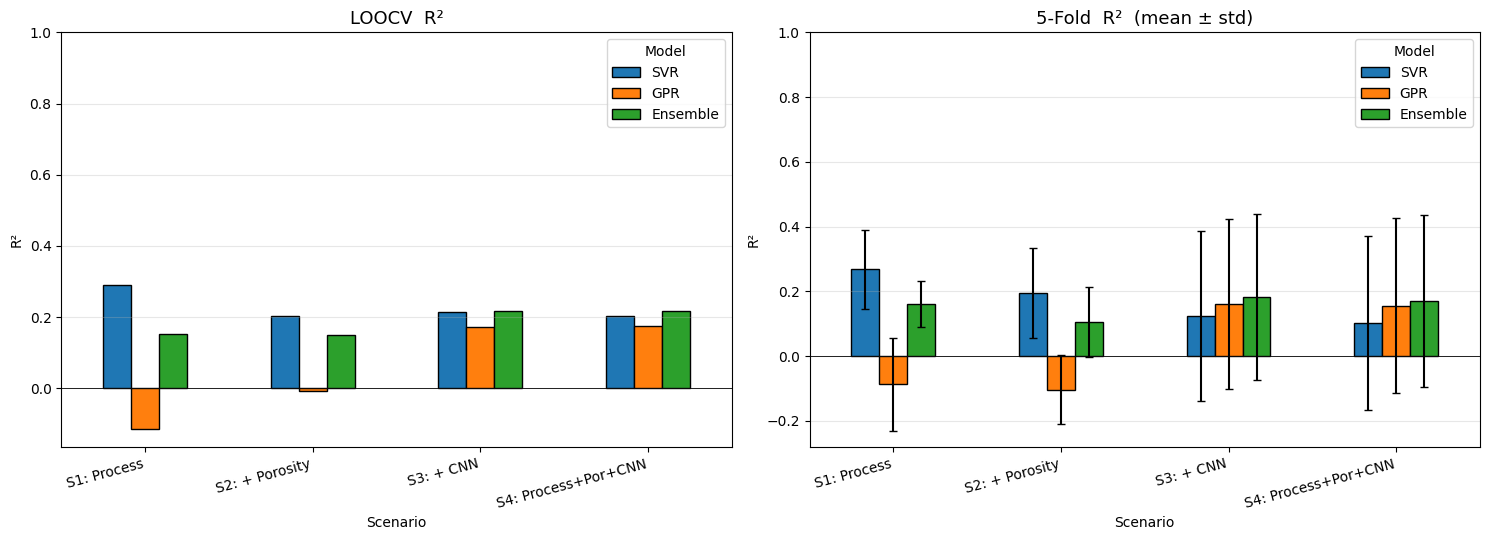

In [44]:
loo_pivot = long_df[long_df['Metric'] == 'LOOCV_R2'].pivot(
    index='Scenario', columns='Model', values='Value'
)[['SVR', 'GPR', 'Ensemble']]
kf_mean   = long_df[long_df['Metric'] == 'KFold5_mean'].pivot(
    index='Scenario', columns='Model', values='Value'
)[['SVR', 'GPR', 'Ensemble']]
kf_std    = long_df[long_df['Metric'] == 'KFold5_std'].pivot(
    index='Scenario', columns='Model', values='Value'
)[['SVR', 'GPR', 'Ensemble']]

scen_order = list(all_results.keys())
loo_pivot = loo_pivot.reindex(scen_order)
kf_mean   = kf_mean.reindex(scen_order)
kf_std    = kf_std.reindex(scen_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
loo_pivot.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('LOOCV  R²', fontsize=13)
axes[0].set_ylabel('R²'); axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_ylim(min(0, loo_pivot.values.min()) - 0.05, 1.0)
axes[0].legend(title='Model'); axes[0].grid(axis='y', alpha=0.3)

kf_mean.plot(kind='bar', yerr=kf_std, ax=axes[1], edgecolor='black', capsize=3)
axes[1].set_title('5-Fold  R²  (mean ± std)', fontsize=13)
axes[1].set_ylabel('R²'); axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_ylim(min(0, (kf_mean - kf_std).values.min()) - 0.05, 1.0)
axes[1].legend(title='Model'); axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('results/scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Best 모델 — Actual vs Predicted (LOOCV)

Best: S1: Process / SVR  (LOOCV R² = 0.2895)


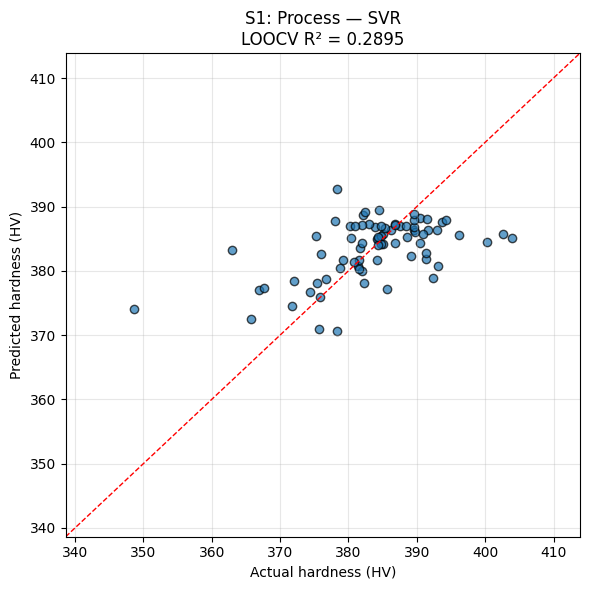

In [45]:
# 최고 LOOCV R² 조합 찾기
best_idx = long_df[long_df['Metric'] == 'LOOCV_R2']['Value'].idxmax()
best_row = long_df.loc[best_idx]
best_scen, best_model = best_row['Scenario'], best_row['Model']
print(f'Best: {best_scen} / {best_model}  (LOOCV R² = {best_row["Value"]:.4f})')

X_best = {'S1: Process': X_s1, 'S2: + Porosity': X_s2,
          'S3: + CNN':   X_s3, 'S4: Process+Por+CNN': X_s4}[best_scen]
Xs = MinMaxScaler().fit_transform(X_best)

preds = np.zeros_like(y)
for tr, te in LeaveOneOut().split(Xs):
    preds[te] = fit_predict(best_model, Xs[tr], y[tr], Xs[te])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, preds, alpha=0.7, edgecolor='k')
lim = [min(y.min(), preds.min()) - 10, max(y.max(), preds.max()) + 10]
ax.plot(lim, lim, 'r--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual hardness (HV)')
ax.set_ylabel('Predicted hardness (HV)')
ax.set_title(f'{best_scen} — {best_model}\nLOOCV R² = {r2_score(y, preds):.4f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/scenario_best_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()